# 07 Appendix: Calibration Sample Size

Tests the calibration sample-size proposition and the appendix quantile-concentration lemma. The diagnostic resamples calibration blocks, recomputes the same component support-function radii used by the robust selector, reruns the selector, and compares quantile error to the empirical decision margin.

In [1]:
from pathlib import Path
import sys

CODE_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(CODE_DIR))

import pandas as pd

from src.experiments import calibration_sample_size_diagnostic
from src.figures import plot_calibration_sample_size
from src.tables import write_table


The default run uses longer calibrated streaming panels than the main-body experiments so the resampling grid has enough calibration blocks to test the sample-size result. The public datasets still calibrate the response, inventory, demand, and member-experience scales; only the number of generated streaming blocks is increased for this appendix stress test.

In [2]:
diagnostics = []
references = []

for case in ['criteo', 'kuairand']:
    print(f'Running calibration sample-size diagnostic for {case}...', flush=True)
    diag, ref = calibration_sample_size_diagnostic(
        case_name=case,
        model='numpy_mlp',
        max_rows=500_000,
        n_blocks=480,
        n_repeats=48,
    )
    diagnostics.append(diag)
    references.append(ref)

diagnostic = pd.concat(diagnostics, ignore_index=True)
reference = pd.concat(references, ignore_index=True)

write_table(diagnostic, '07_calibration_sample_size_diagnostic.csv')
write_table(reference, '07_calibration_sample_size_reference.csv')

reference


Running calibration sample-size diagnostic for criteo...
[forecast] fitting 1 forecasters: blocks=480, dim=48, train_blocks=240
[forecast] numpy_mlp start
[forecast] numpy_mlp training start: epochs=600, hidden=48
[forecast] numpy_mlp epoch 1/600, train_mse=1.05884
[forecast] numpy_mlp epoch 120/600, train_mse=0.904165
[forecast] numpy_mlp epoch 240/600, train_mse=0.861605
[forecast] numpy_mlp epoch 360/600, train_mse=0.854522
[forecast] numpy_mlp epoch 480/600, train_mse=0.849393
[forecast] numpy_mlp epoch 600/600, train_mse=0.844693
[forecast] numpy_mlp done in 0.1s, train_mse=662424, band_radius=3905.6
Running calibration sample-size diagnostic for kuairand...
[forecast] fitting 1 forecasters: blocks=480, dim=48, train_blocks=240
[forecast] numpy_mlp start
[forecast] numpy_mlp training start: epochs=600, hidden=48
[forecast] numpy_mlp epoch 1/600, train_mse=1.07592
[forecast] numpy_mlp epoch 120/600, train_mse=0.659153
[forecast] numpy_mlp epoch 240/600, train_mse=0.624681
[forecast

,case,model,n_blocks,n_full_calibration_blocks,reference_policy,reference_has_certified_policy,reference_shortlist_size,reference_q_decision,reference_q_value,reference_q_delivery,...,decision_margin,half_margin,alpha,alpha_tau,alpha_m,component_alpha,tau_se,member_se,true_value,any_violation_rate
0,criteo,numpy_mlp,480,120,pace_i3_q2,True,3,31.287548,73.820234,3613.025621,...,72.809087,36.404543,0.1,0.1,0.1,0.025,0.000460,0.001548,518.546347,0.008333
1,kuairand,numpy_mlp,480,120,unresolved,False,1,344.340956,502.585509,4848.605667,...,3674.620961,1837.310480,0.1,0.1,0.1,0.025,0.000411,0.059318,NaN,NaN


In [3]:
summary = (
    diagnostic.groupby(['case', 'n_calibration_blocks'])
    .agg(
        median_max_component_error=('max_component_quantile_error', 'median'),
        p25_max_component_error=('max_component_quantile_error', lambda x: x.quantile(0.25)),
        p75_max_component_error=('max_component_quantile_error', lambda x: x.quantile(0.75)),
        same_decision_state_rate=('same_decision_state', 'mean'),
        same_policy_rate=('same_reference_policy', 'mean'),
        theorem_margin_condition_rate=('theorem_margin_condition', 'mean'),
        median_shortlist_size=('shortlist_size', 'median'),
    )
    .reset_index()
)
write_table(summary, '07_calibration_sample_size_summary.csv')
summary


,case,n_calibration_blocks,median_max_component_error,p25_max_component_error,p75_max_component_error,same_decision_state_rate,same_policy_rate,theorem_margin_condition_rate,median_shortlist_size
0,criteo,8,1862.875027,1223.143951,1963.307241,0.250000,0.25,0.041667,3.0
1,criteo,12,1871.305537,1056.827896,2251.899660,0.333333,0.333333,0.020833,3.0
2,criteo,16,1254.598795,199.371025,2137.021220,0.458333,0.458333,0.187500,3.0
3,criteo,24,840.973322,657.052129,1848.442598,0.625000,0.625,0.125000,3.0
4,criteo,32,657.052129,199.371025,1832.463892,0.687500,0.6875,0.166667,3.0
5,criteo,48,840.973322,199.371025,20471.150155,0.562500,0.5625,0.104167,3.0
6,criteo,64,11134.038498,199.371025,20471.150155,0.479167,0.479167,0.125000,2.0
7,criteo,96,199.371025,149.528268,199.371025,1.000000,1.0,0.250000,3.0
8,criteo,120,0.000000,0.000000,0.000000,1.000000,1.0,1.000000,3.0
9,kuairand,8,1065.465703,425.121508,1367.284355,0.979167,NaN,0.000000,1.0


PosixPath('/home/apex/Documents/ranking_sys/notebooks/writing/forecast_calibrated_causal_pacing_yield_optimization_streaming_ads/code/artifacts/figures/appendix_calibration_sample_size.png')

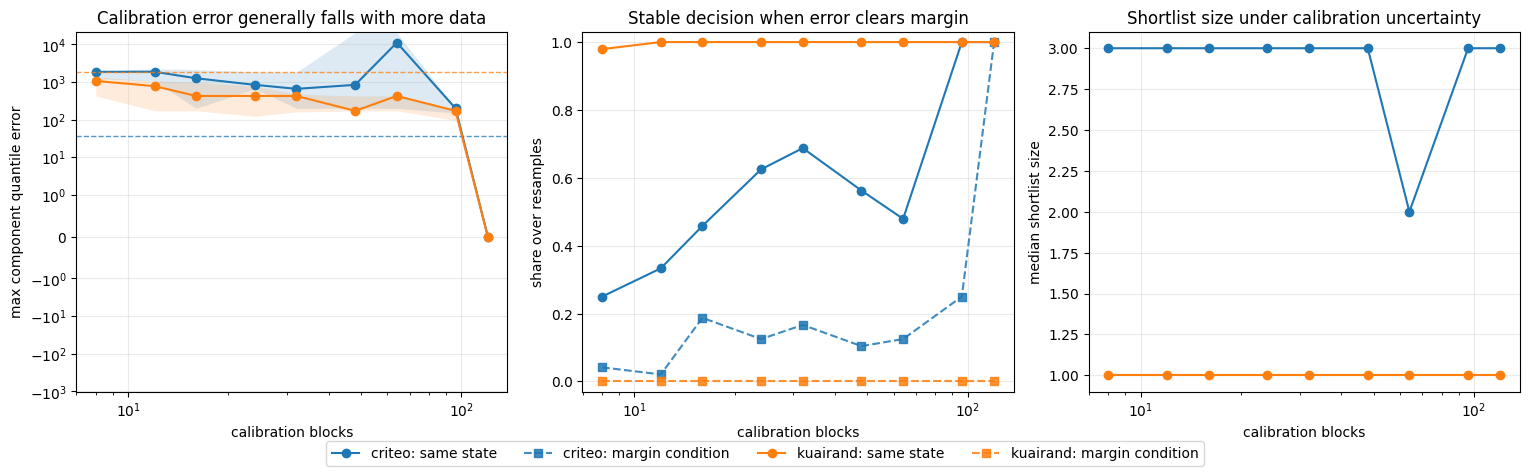

In [4]:
plot_calibration_sample_size(diagnostic, reference, 'appendix_calibration_sample_size.png')
